In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch as torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger(__name__)


In [41]:
from xml.parsers.expat import model


class LSTMAutoEncorder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LSTMAutoEncorder, self).__init__()
        self.encoder = nn.LSTM(
            input_size=input_dim, 
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.decoder = nn.LSTM(
            input_size=hidden_dim, 
            hidden_size=input_dim, 
            batch_first=True
        )
        self.output_layer = nn.Linear(input_dim, input_dim)

    def encode(self, x):
        _, (hidden, _) = self.encoder(x)
        return hidden[-1]  # 最後の層の隠れ状態を返す

    def forward(self, x):
        hidden_vec = self.encode(x)
        decoder_input = hidden_vec.unsqueeze(0).repeat(x.size(1), 1, 1).permute(1, 0, 2)
        decoder_output, _ = self.decoder(decoder_input)
        output = self.output_layer(decoder_output)
        return output
    
def create_sequences(data, seq_len, feature_cols):
    sequences = []
    for unit_id in data["unit_number"].unique():
        unit_df = data[data["unit_number"] == unit_id]
        unit_df = unit_df.sort_values("time_in_cycles")
        values = unit_df[feature_cols].values
        for i in range(len(unit_df) - seq_len + 1):
            seq = values[i:i+seq_len]
            sequences.append(seq)
    return np.array(sequences)

def evaluate(model, X):
    model.eval()
    with torch.no_grad():
        reconstructed = model(X)
        loss = ((X - reconstructed) ** 2).mean(dim=(1, 2))
    return loss

def extract_normal_period(data, normal_ratio=0.5):
    normal_rows = []

    for unit_id in data["unit_number"].unique():
        unit_df = data[data["unit_number"] == unit_id]
        unit_df = unit_df.sort_values("time_in_cycles")

        cutoff = int(len(unit_df) * normal_ratio)
        normal_rows.append(unit_df.iloc[:cutoff])

    return pd.concat(normal_rows)

def evaluate_with_cycle(model, data, seq_len, feature_cols):
    data = data.sort_values(["unit_number", "time_in_cycles"])
    rows = []

    for unit_id in data["unit_number"].unique():
        unit_df = data[data["unit_number"] == unit_id].sort_values("time_in_cycles")
        unit_seq = create_sequences(unit_df, seq_len=seq_len, feature_cols=feature_cols)

        if len(unit_seq) == 0:
            continue

        unit_tensor = torch.tensor(unit_seq, dtype=torch.float32)
        errors = evaluate(model, unit_tensor).numpy()

        cycle = unit_df["time_in_cycles"].values[seq_len - 1:]
        cycle_norm = unit_df["cycle_norm"].values[seq_len - 1:]

        temp_pd = pd.DataFrame({
            "unit_number": unit_id,
            "cycle": cycle,
            "cycle_norm": cycle_norm,
            "error": errors
        })

        X_tensor = torch.tensor(unit_seq, dtype=torch.float32) 
        reconstructed = model(X_tensor)

        sensor_error = (
            (X_tensor - reconstructed) ** 2
        ).mean(dim=1)

        for i , col in enumerate(feature_cols):
            temp_pd[f"sensor_error_{col}"] = (
                sensor_error[:, i].cpu().detach().numpy()
            )
        rows.append(temp_pd)

    return pd.concat(rows, ignore_index=True)

def extract_latent_with_cycle(model, data, seq_len, feature_cols):
    data = data.sort_values(["unit_number", "time_in_cycles"])
    rows = []

    model.eval()
    with torch.no_grad():
        for unit_id in data["unit_number"].unique():
            unit_df = data[data["unit_number"] == unit_id].sort_values("time_in_cycles")
            unit_seq = create_sequences(unit_df, seq_len=seq_len, feature_cols=feature_cols)

            if len(unit_seq) == 0:
                continue

            unit_tensor = torch.tensor(unit_seq, dtype=torch.float32)
            latent = model.encode(unit_tensor).numpy()

            meta = pd.DataFrame({
                "unit_number": unit_id,
                "cycle": unit_df["time_in_cycles"].values[seq_len - 1:],
                "cycle_norm": unit_df["cycle_norm"].values[seq_len - 1:]
            })

            latent_df = pd.DataFrame(latent, columns=[f"z{i}" for i in range(latent.shape[1])])
            rows.append(pd.concat([meta.reset_index(drop=True), latent_df], axis=1))

    return pd.concat(rows, ignore_index=True)

In [42]:
#Day16 Task1 推論関数整理
def predict_anomaly(
        sequence,
        model=None,
        scaler=None,
        seq_len=10,
        feature_cols=None,
        rolling_window=10,
        threshold=0.8,
        consecutive_window=5
    ):
        """
        reprocess -> reconstruction error -> rolling -> alert for inference.
        """
        if model is None:
            model = globals()["model"]
        if scaler is None:
            scaler = globals()["scaler"]
        if feature_cols is None:
            feature_cols = globals()["feature_cols"]
    
        data = sequence.copy()
    
        if "cycle_norm" not in data.columns:
            data["cycle_norm"] = data.groupby("unit_number")["time_in_cycles"].transform(
                lambda x: x / x.max()
            )
    
        data = data.sort_values(["unit_number", "time_in_cycles"]).reset_index(drop=True)
        data[feature_cols] = scaler.transform(data[feature_cols])
    
        result = evaluate_with_cycle(
            model,
            data,
            seq_len=seq_len,
            feature_cols=feature_cols
        )
    
        result["rolling_error"] = (
            result
            .groupby("unit_number")["error"]
            .transform(lambda x: x.rolling(window=rolling_window, min_periods=1).mean())
        )
        result["alert"] = result["rolling_error"] > threshold
    
        alert_group = result.groupby("unit_number")["alert"].transform(
            lambda x: (x != x.shift()).cumsum()
        )
        result["consecutive"] = (
            result["alert"]
            .astype(int)
            .groupby([result["unit_number"], alert_group])
            .cumsum()
        )
        result["final_alert"] = result["consecutive"] >= consecutive_window
    
        return result

In [ ]:
#Day16 Task2 FastAPI
import json
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

app = FastAPI()

#Day17 Task3 POST /predict
class PredictRequest(BaseModel):
    sequence: list[dict]
    seq_len: int = 10
    rolling_window: int = 10
    threshold: float = 0.8
    consecutive_window: int = 5

@app.post("/predict")
def predict(request: PredictRequest):
    try:
        logger.info("Received prediction request")

        sequence_df = pd.DataFrame(request.sequence)

        logger.info(
            f"Input rows={len(sequence_df)}, "
            f"seq_len={request.seq_len}, "
            f"threshold={request.threshold}"
        )

        result = predict_anomaly(
            sequence_df,
            seq_len=request.seq_len,
            rolling_window=request.rolling_window,
            threshold=request.threshold,
            consecutive_window=request.consecutive_window
        )
        result = result.replace([np.inf, -np.inf], np.nan)
        result = result.fillna(0)
        latest = result.sort_values(["unit_number", "time_in_cycles"]).iloc[-1]
        severity = "normal"
        if bool(latest["final_alert"]):
            severity = "critical"
        elif bool(latest["alert"]):
            severity = "warning"

        logger.info(
            f"Prediction result: "
            f"unit={latest['unit_number']}, "
            f"cycle={latest['cycle']}, "
            f"error={latest['error']:.4f}, "
            f"rolling_error={latest['rolling_error']:.4f}, "
            f"severity={severity}"
        )

        sensor_errors = latest[
            [c for c in result.columns if c.startswith("sensor_error_")]
        ]

        top_sensors = (
            sensor_errors
            .sort_values(ascending=False)
            .head(5)
        )

        top_sensor_errors = [
            {
                "sensor": sensor_name.replace("sensor_error_", ""),
                "error": float(error_value)
            }
            for sensor_name, error_value in top_sensors.items()
        ]

        return {
            "unit_number": int(latest["unit_number"]),
            "time_in_cycles": int(latest["time_in_cycles"]),
            "error": float(latest["error"]),
            "rolling_error": float(latest["rolling_error"]),
            "threshold": request.threshold,
            "alert": bool(latest["alert"]),
            "final_alert": bool(latest["final_alert"]),
            "severity": severity,
            "tpo_sensor_errors": top_sensor_errors
        }
    except KeyError as e:
        logger.warning(f"Bad request: missing column {e}")
        raise HTTPException(status_code=400, detail=f"Missing required column: {e}")
    except Exception as e:
        logger.exception("Prediction failed")
        raise HTTPException(status_code=500, detail=str(e))

<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\kazuk\AppData\Local\Temp\ipykernel_15072\1200469063.py:2: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv("../data/raw/train_FD001.txt", sep="\s+", header=None)


Epoch 1/50, Loss: 0.6387
Epoch 11/50, Loss: 0.6018
Epoch 21/50, Loss: 0.5628
Epoch 31/50, Loss: 0.5081
Epoch 41/50, Loss: 0.4396
          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


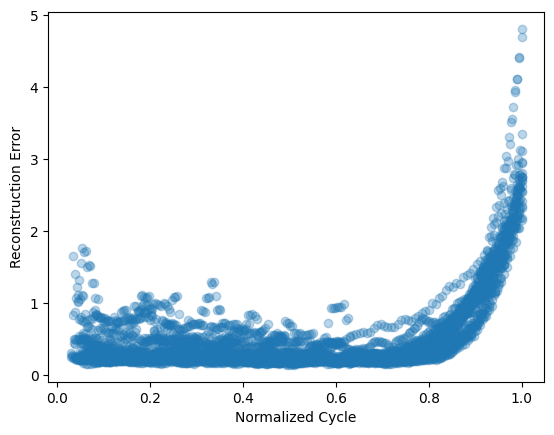

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


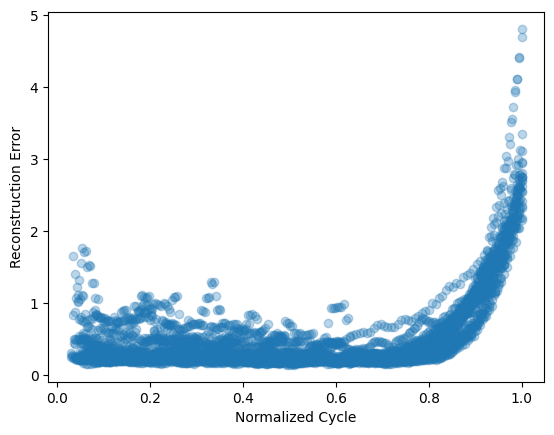

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


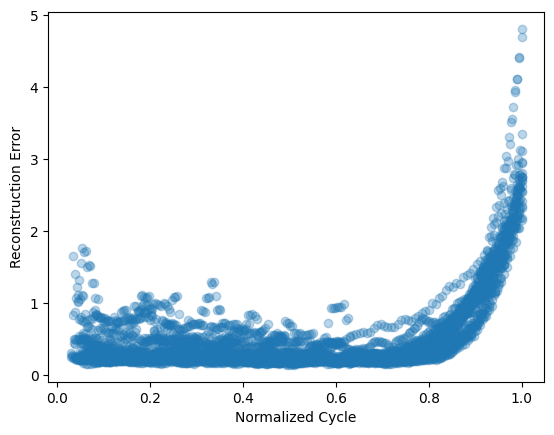

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


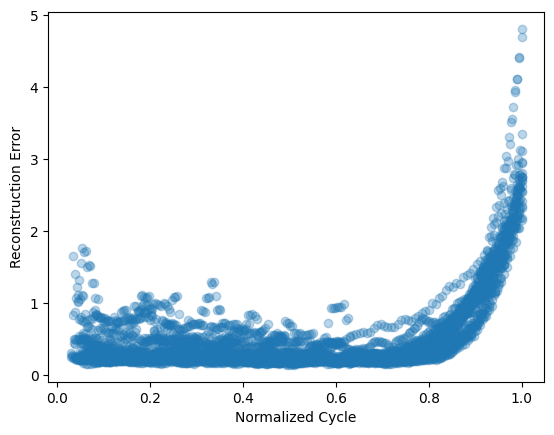

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


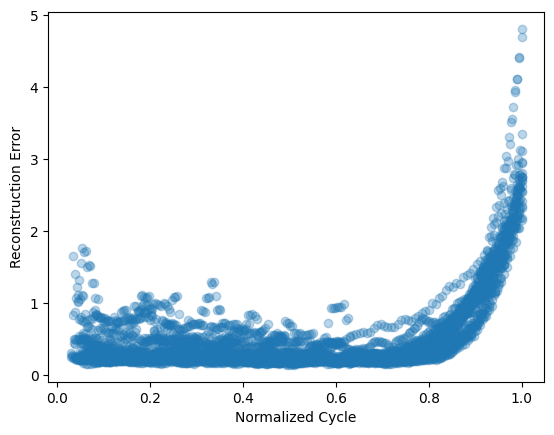

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


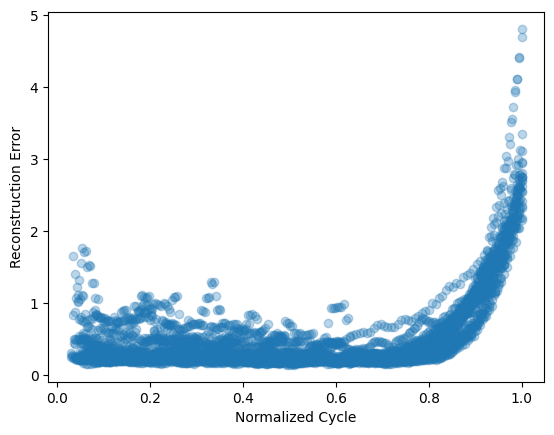

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


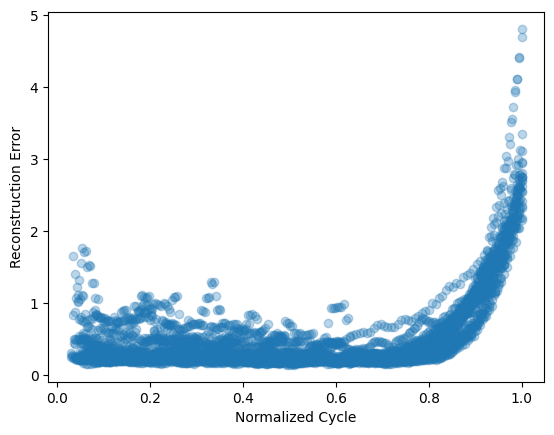

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


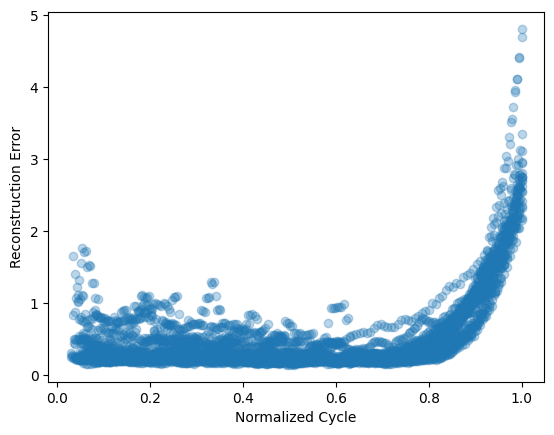

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


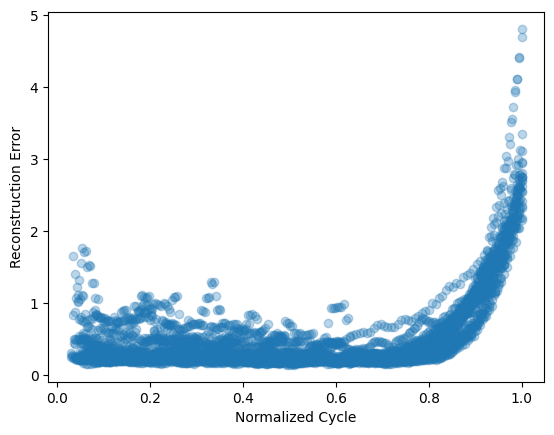

          error     cycle
error  1.000000  0.419236
cycle  0.419236  1.000000
               error  cycle_norm
error       1.000000    0.490615
cycle_norm  0.490615    1.000000


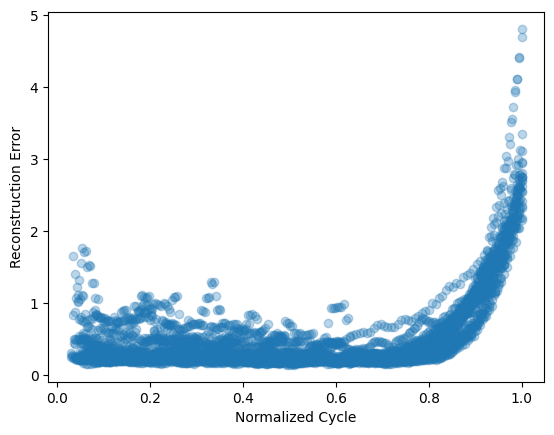

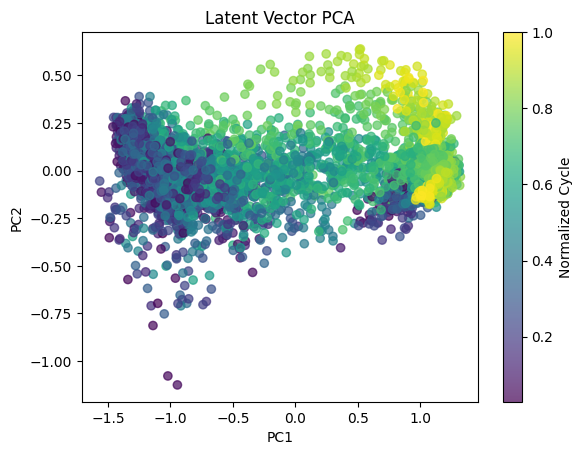

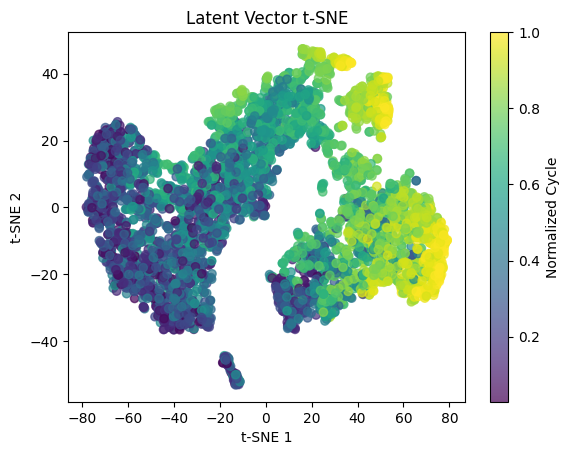

In [44]:
# 1.NASA Turbofan データセット取得
df = pd.read_csv("../data/raw/train_FD001.txt", sep="\s+", header=None)
df.columns = ["unit_number", "time_in_cycles"] + [f"ope_setting{i}" for i in range(1, 4)] + [f"sensor_ms{i}" for i in range(1, 22)]
df["cycle_norm"] = df.groupby("unit_number")["time_in_cycles"].transform(lambda x:x / x.max())
# unit_number, time_in_cycles を確認
df.head(50)
# 3.センサー列を選択
feature_cols = [f"sensor_ms{i}" for i in range(1, 22)]
df_sensors = df[["unit_number", "time_in_cycles", "cycle_norm"] + [f"sensor_ms{i}" for i in range(1, 22)]]
train_units = df["unit_number"].unique()[:80]
test_units = df["unit_number"].unique()[80:]

train_df = df[df["unit_number"].isin(train_units)]
test_df = df[df["unit_number"].isin(test_units)]

scaler = StandardScaler()
train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df_scaled[feature_cols] = scaler.transform(test_df[feature_cols])

normal_train_df = extract_normal_period(train_df_scaled, normal_ratio=0.5)
# 4.unitごとに時系列順で並べる
train_df.sort_values(["unit_number", "time_in_cycles"], inplace=True)
# 5.正常区間から window を作成
X_train_seq = create_sequences(normal_train_df, seq_len=10, feature_cols=feature_cols)
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
# 6.LSTM AutoEncoderで学習
model = LSTMAutoEncorder(input_dim=len(feature_cols), hidden_dim=10)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    reconstructed = model(X_train_tensor)
    optimizer.zero_grad()
    loss = criterion(reconstructed, X_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# 7.Reconstruction Errorを時系列プロット
for unit_id in range(81, 91):
    unit_df = test_df_scaled[test_df_scaled["unit_number"] == unit_id]
    unit_seq = create_sequences(unit_df, seq_len=10, feature_cols=feature_cols)
    unit_tensor = torch.tensor(unit_seq, dtype=torch.float32)
    error_df = evaluate_with_cycle(model, test_df_scaled, seq_len=10, feature_cols=feature_cols)

    print(error_df[["error", "cycle"]].corr())
    print(error_df[["error", "cycle_norm"]].corr())

    plt.scatter(error_df["cycle_norm"], error_df["error"], alpha=0.3)
    plt.xlabel("Normalized Cycle")
    plt.ylabel("Reconstruction Error")
    plt.show()

latent_df = extract_latent_with_cycle(model, test_df_scaled, seq_len=10, feature_cols=feature_cols)
latent_cols = [c for c in latent_df.columns if c.startswith("z")]

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_df[latent_cols])

plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=latent_df["cycle_norm"], cmap="viridis", alpha=0.7)
plt.colorbar(label="Normalized Cycle")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent Vector PCA")
plt.show()


tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
latent_tsne = tsne.fit_transform(latent_df[latent_cols])

plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=latent_df["cycle_norm"], cmap="viridis", alpha=0.7)
plt.colorbar(label="Normalized Cycle")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Latent Vector t-SNE")
plt.show()

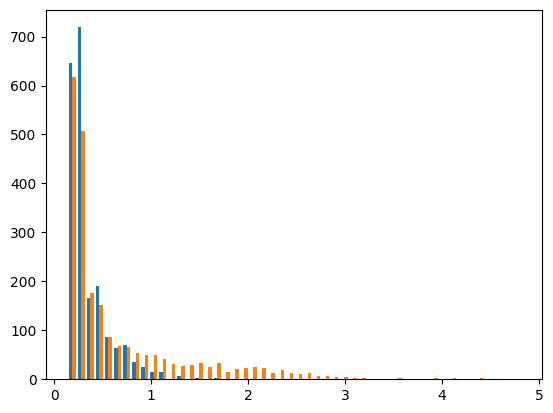

0.3 normal:807
0.3 deg:1224
0.5 normal:357
0.5 deg:823
0.8 normal:100
0.8 deg:581


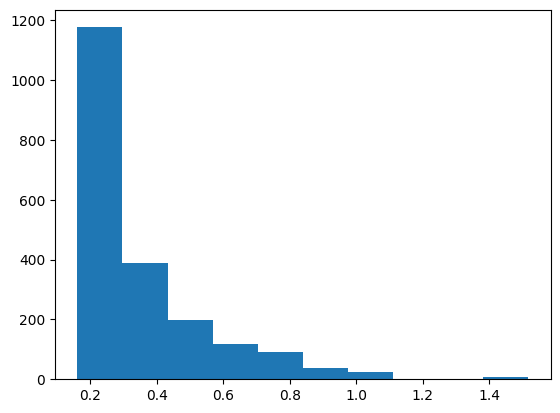

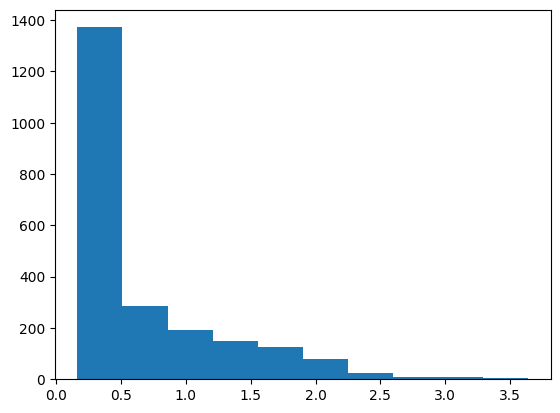

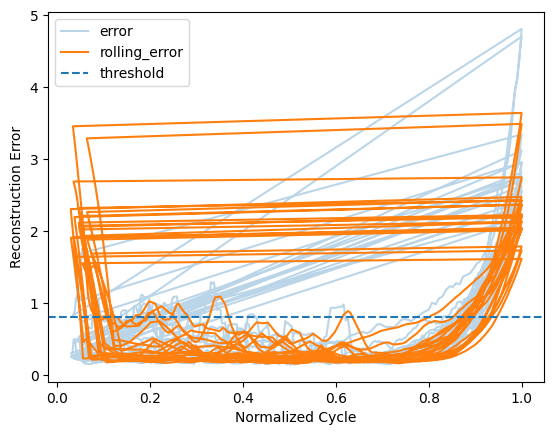

,unit_number,cycle,cycle_norm,error,sensor_error_sensor_ms1,sensor_error_sensor_ms2,sensor_error_sensor_ms3,sensor_error_sensor_ms4,sensor_error_sensor_ms5,sensor_error_sensor_ms6,...,sensor_error_sensor_ms15,sensor_error_sensor_ms16,sensor_error_sensor_ms17,sensor_error_sensor_ms18,sensor_error_sensor_ms19,sensor_error_sensor_ms20,sensor_error_sensor_ms21,phase,rolling_error,alert
200,81,210,0.875000,0.938967,0.002551,1.252837,1.891158,1.005032,0.035319,0.043351,...,1.511530,0.013263,1.503136,0.000200,0.002165,1.335242,1.139807,degradation,0.804008,True
201,81,211,0.879167,1.026698,0.001785,1.819082,1.893558,1.014709,0.032006,0.047070,...,1.767093,0.013837,2.154879,0.000585,0.001902,1.333236,1.169964,degradation,0.836392,True
202,81,212,0.883333,1.071298,0.001578,1.910230,2.020944,1.079920,0.032237,0.050555,...,1.858200,0.014272,2.153617,0.000777,0.001914,1.311750,1.101645,degradation,0.875506,True
203,81,213,0.887500,1.084103,0.001836,1.768420,2.007378,1.539658,0.030021,0.047577,...,1.852496,0.013136,1.962342,0.000520,0.002019,1.384246,1.040495,degradation,0.907112,True
204,81,214,0.891667,1.123087,0.002330,1.840743,1.640217,1.335845,0.029029,0.042002,...,2.483135,0.011941,2.151808,0.000333,0.002281,1.171437,1.176216,degradation,0.940769,True


In [45]:
# Task1: Error分布分析
test_number = 81
unit2_df_scaled = test_df_scaled[test_df_scaled["unit_number"] == test_number]
errors2 = evaluate_with_cycle(model, test_df_scaled, seq_len=10, feature_cols=feature_cols)
normal_errors = errors2[errors2["cycle_norm"] < 0.5]["error"]
degradation_errors = errors2[errors2["cycle_norm"] >= 0.5]["error"]
plt.hist([normal_errors, degradation_errors], bins=50, label=["Normal, Degradation"])
plt.show()

# Task2: threshold最適化
def getConfusionMatrix(df_result, threshold):
    errors2["phase"] = np.where(
        errors2["cycle_norm"] < 0.5,
        "normal",
        "degradation"
    )
    normal_alert = ((errors2["phase"] == "normal") &
            (errors2["error"] > threshold)
    ).sum()
    deg_errors = ((errors2["phase"] == "degradation") &
            (errors2["error"] > threshold)
    ).sum()

    return normal_alert, deg_errors

normal, degrad = getConfusionMatrix(errors2, 0.3)
print(f"0.3 normal:{normal}")
print(f"0.3 deg:{degrad}")
normal, degrad = getConfusionMatrix(errors2, 0.5)
print(f"0.5 normal:{normal}")
print(f"0.5 deg:{degrad}")
normal, degrad = getConfusionMatrix(errors2, 0.8)
print(f"0.8 normal:{normal}")
print(f"0.8 deg:{degrad}")

# Task3: Rolling Error
rolling_normal_errors = (
    pd.Series(normal_errors).rolling(10).mean()
)
rolling_deg_errors = (
    pd.Series(degradation_errors).rolling(10).mean()
)
plt.hist(rolling_normal_errors)
plt.show()
plt.hist(rolling_deg_errors)
plt.show()

errors2["rolling_error"] = (
    errors2["error"]
    .rolling(window=10)
    .mean()
)

plt.plot(errors2["cycle_norm"], errors2["error"], alpha=0.3, label="error")
plt.plot(errors2["cycle_norm"], errors2["rolling_error"], label="rolling_error")
plt.axhline(0.8, linestyle="--", label="threshold")
plt.xlabel("Normalized Cycle")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.show()

errors2["alert"] = errors2["rolling_error"] > 0.8
errors2[errors2["alert"]].head()
# Task4: Drift検知



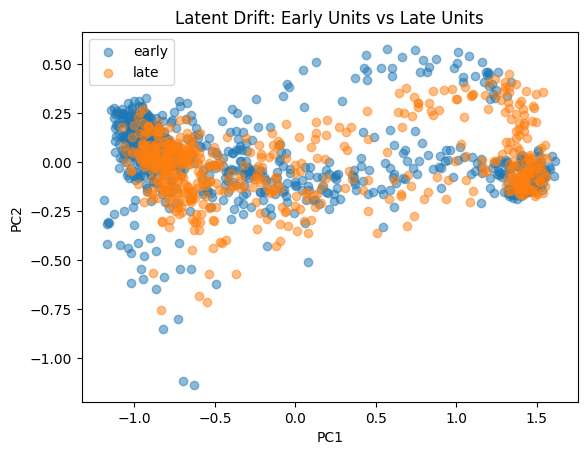

unit 81
         sensor     error
11  sensor_ms12  0.900342
12  sensor_ms13  0.879339
14  sensor_ms15  0.828044
16  sensor_ms17  0.817519
7    sensor_ms8  0.815833
unit 82
         sensor     error
8    sensor_ms9  3.064127
13  sensor_ms14  2.561459
5    sensor_ms6  2.506849
3    sensor_ms4  1.316232
16  sensor_ms17  0.938910
unit 83
         sensor     error
5    sensor_ms6  2.595103
11  sensor_ms12  1.218644
3    sensor_ms4  1.187407
1    sensor_ms2  0.982132
20  sensor_ms21  0.905223


In [46]:
# Task4: Drift検知
early_units = [81,82,83]
late_units = [88,89,90]

early_errors = []
late_errors = []

early_pca = PCA(early_units)
late_pca = PCA(late_units)

dfs = []

for unit in early_units:
    unit_df_scaled = test_df_scaled[test_df_scaled["unit_number"] == unit]
    tmp = extract_latent_with_cycle(
        model, unit_df_scaled, seq_len=10, feature_cols=feature_cols
    )
    tmp["group"] = "early"
    tmp["unit_number"] = unit
    dfs.append(tmp)

for unit in late_units:
    unit_df_scaled = test_df_scaled[test_df_scaled["unit_number"] == unit]
    tmp = extract_latent_with_cycle(
        model, unit_df_scaled, seq_len=10, feature_cols=feature_cols
    )
    tmp["group"] = "late"
    tmp["unit_number"] = unit
    dfs.append(tmp)

latent_df = pd.concat(dfs, ignore_index=True)

latent_cols = [c for c in latent_df.columns if c.startswith("z")]

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_df[latent_cols])

latent_df["PC1"] = latent_2d[:, 0]
latent_df["PC2"] = latent_2d[:, 1]

for group in ["early", "late"]:
    tmp = latent_df[latent_df["group"] == group]
    plt.scatter(
        tmp["PC1"],
        tmp["PC2"],
        alpha=0.5,
        label=group
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent Drift: Early Units vs Late Units")
plt.legend()
plt.show()


# Task5: 連続超過検知
errors2["alert"] = (
    errors2["rolling_error"] > 0.8
)

errors2["consecutive"] = (
    errors2
    .groupby("unit_number")["alert"]
    .transform(
        lambda x:
        x.astype(int)
         .groupby(
            (x != x.shift()).cumsum()
         )
         .cumsum()
    )
)

errors2["final_alert"] = (
    errors2["consecutive"] >= 5
)
errors2[errors2["consecutive"] > 0].head(50)

#Task6: sensor分析
def evaluate_sensor_error(model, X):
    model.eval()
    with torch.no_grad():
        reconstructed = model(X)
        loss = ((X - reconstructed) ** 2).mean(dim=(0,1))
    return loss

for index in early_units:
    unit_df_scaled = test_df_scaled[test_df_scaled["unit_number"] == index]
    seq = create_sequences(unit_df_scaled, seq_len=10, feature_cols=feature_cols)
    seq_tensor  = torch.tensor(seq, dtype=torch.float32)

    sensor_error = evaluate_sensor_error(model, seq_tensor)

    result = pd.DataFrame({
        "sensor": feature_cols,
        "error": sensor_error.numpy()
    }).sort_values("error", ascending=False)

    print(f"unit {index}")
    print(result.head(5))
